<a href="https://colab.research.google.com/github/RHM-Romim/NSDA-Level6_tasks/blob/main/Set1_job3_Sentiment_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> Job 03-Working Procedure/ Steps:
1. Wear the required Personal Protective Equipment (PPE) for the job.
2. Observe and follow appropriate occupational health and safety (OHS) requirements during the demonstration.
3. Check Electricity, Peripheral device & Internet Connections to your Computer.
4. Start the Computer.
5. Check for software errors and troubleshoot problems.
6. Collect the required resources (dataset and materials) from the assessor as per the job requirement.
7. Create a Sentiment Analysis System using Deep Learning
8. Set up the Python environment required to complete the project.
9. Load and inspect the dataset.
10. Prepare the data (cleaning, noise removal, and data annotation).
11. Extract relevant features and transform the data (e.g., tokenization,embedding, normalization).
12. Split the dataset into training, validation, and testing sets. (added – mandatory for DL)
13. Design the deep learning model architecture.
14. Compile and train the model.
15. Evaluate the model performance using appropriate metrics.
16. Visualize model performance (loss, accuracy, or error trends).
17. Detect overfitting and underfitting using training and validation results.
18. Save and deploy the final trained model.
19. Submit the final output to the competency assessor.
20. Shut down the computer and clean your workplace.
21. Clean tools, equipment, materials, and work area.



### Task 8: Set up the Python environment
### Task 9: Load and inspect the dataset

This step involves importing necessary libraries and loading the `Job_3_Resource_sentiment.csv` dataset into a pandas DataFrame, then displaying the first few rows to understand its structure.

In [1]:
# Import the pandas library, which is essential for data manipulation and analysis.
# It allows us to work with DataFrames, which are tabular data structures.
import pandas as pd

# Load the dataset from the specified CSV file path into a pandas DataFrame.
# The dataset '/content/Job_3_Resource_sentiment.csv' is expected to contain sentiment-related text data.
# Initially, we might load it without specifying a header, assuming the first row is data, not column names.
df = pd.read_csv('/content/Job_3_Resource_sentiment.csv')

In [5]:
# Display the first few rows of the DataFrame.
# This is a crucial step for initial data inspection to understand its structure, column names (or lack thereof),
# data types, and potential issues like missing values or incorrect parsing.
# 'df.head()' is a common method for this; 'display(df.head())' is used in environments like Colab for better formatting.
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


#### Task 10.1: Correcting Column Headers and Initial Inspection

In [11]:
# Reload the dataset, explicitly telling pandas that the file does not have a header row.
# This decision is made after inspecting the initial 'df.head()' output, which showed that the first row
# was clearly part of the data and not column labels.
# Rationale: Incorrect header inference can lead to misinterpretation of data.
df = pd.read_csv('/content/Job_3_Resource_sentiment.csv', header=None)

# Assign meaningful column names to the DataFrame.
# Based on the content analysis of the dataset, these names ('ID', 'Game', 'Sentiment', 'Text') are chosen.
# The previous attempt incorrectly included 'Text_Correction_Example' as a column, which was not present in the data,
# leading to an error. This correction aligns the column names with the actual number of columns (4) in the CSV.
# Alternatives: If the dataset came with a separate schema or dictionary, those names would be preferred.
df.columns = ['ID', 'Game', 'Sentiment', 'Text']

# Print a message and display the first few rows again to confirm the column names have been applied correctly.
print("Dataset after correcting column names:")
display(df.head())

# Print a summary of the DataFrame including column data types, non-null counts, and memory usage.
# This helps in identifying columns with missing values and verifying data types (e.g., 'object' for strings).
print("\nDataset Information (after column correction):")
df.info()

Dataset after correcting column names:


,ID,Game,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Dataset Information (after column correction):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Game       74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


#### Task 10.2: Handling Missing Values and Duplicates

In [12]:
# Check for missing values in each column.
# 'df.isnull().sum()' counts the number of NaN (Not a Number) entries per column.
# This helps quantify the extent of missing data, especially in the 'Text' column, which often contains missing entries.
print("\nMissing values per column:")
display(df.isnull().sum())

# Check for duplicate rows in the entire DataFrame.
# 'df.duplicated().sum()' counts rows that are identical to a previous row.
# Duplicates can skew analysis and model training, so identifying them is crucial.
print("\nNumber of duplicate rows before dropping:", df.duplicated().sum())

# Drop duplicate rows to ensure data integrity and prevent model bias.
# 'inplace=True' modifies the DataFrame directly.
# Rationale: Duplicate entries might represent noise or over-representation of certain samples,
# which can lead to overfitting during model training.
# Alternatives: Instead of dropping, one might choose to keep them if they represent valid repeated observations.
df.drop_duplicates(inplace=True)
print("Number of rows after dropping duplicates:", len(df))


Missing values per column:


,0
ID,0
Game,0
Sentiment,0
Text,686



Number of duplicate rows before dropping: 2700
Number of rows after dropping duplicates: 71982


#### Task 10.3: Normalizing Sentiment Labels

In [13]:
# Examine the distribution of the 'Sentiment' column before normalization.
# 'value_counts()' shows the unique values in the column and their frequencies.
# This step reveals inconsistencies like 'Neutral ', 'negative', 'positive', 'Positive', 'neutral', 'Irrelevant', etc.
print("\nSentiment distribution before normalization:")
display(df['Sentiment'].value_counts())

# Clean and normalize the 'Sentiment' column to handle inconsistencies.
# '.str.strip()' removes leading/trailing whitespace (e.g., 'Neutral ' -> 'Neutral').
# '.str.lower()' converts all text to lowercase (e.g., 'Positive' -> 'positive', 'Negative' -> 'negative').
# This ensures that all variations of a sentiment label are treated as the same category.
# Rationale: Consistency is vital for accurate categorical encoding and model training.
# Alternatives: Custom mapping functions for more complex normalization or using fuzzy matching if labels are highly varied.
df['Sentiment'] = df['Sentiment'].str.strip().str.lower()

# Display the sentiment distribution after normalization to confirm the changes.
print("\nSentiment distribution after normalization:")
display(df['Sentiment'].value_counts())


Sentiment distribution before normalization:


,count
Sentiment,
Negative,21787
Positive,19811
Neutral,17800
Irrelevant,12584



Sentiment distribution after normalization:


,count
Sentiment,
negative,21787
positive,19811
neutral,17800
irrelevant,12584


#### Task 10.4: Basic Text Cleaning

In [14]:
import re # Import the regular expression module for advanced string operations.

# Define a function to clean the text data.
def clean_text(text):
    # Convert the input text to a string and then to lowercase.
    # This ensures uniformity and handles potential non-string inputs gracefully.
    text = str(text).lower()  # Rationale: Case-insensitivity reduces vocabulary size and treats 'Good' and 'good' as the same.

    # Remove special characters, keeping only alphanumeric characters and spaces.
    # '[^a-z0-9\s]' matches any character that is NOT a lowercase letter, a digit, or a whitespace character.
    # Alternatives: Keep punctuation for sentiment if it conveys meaning (e.g., '!' or '?'), but for basic NLP, it's often removed.
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Replace multiple spaces with a single space and remove leading/trailing spaces.
    # '\s+' matches one or more whitespace characters.
    # '.strip()' removes any whitespace from the beginning or end of the string.
    # Rationale: Standardizes spacing and removes extraneous whitespace.
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply the 'clean_text' function to the 'Text' column and store the results in a new 'cleaned_text' column.
# The '.apply()' method is used to execute a function on each element of a Series (DataFrame column).
df['cleaned_text'] = df['Text'].apply(clean_text)

# Print and display examples of original vs. cleaned text to verify the cleaning process.
print("Original Text vs. Cleaned Text examples:")
display(df[['Text', 'cleaned_text']].head())

Original Text vs. Cleaned Text examples:


,Text,cleaned_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...


#### Task 11: Extract relevant features and transform the data (Tokenization, Embedding, Normalization)

In [15]:
import numpy as np # Import NumPy for numerical operations, especially with arrays.
from tensorflow.keras.preprocessing.text import Tokenizer # Import Tokenizer for converting text to sequences of integers.
from tensorflow.keras.preprocessing.sequence import pad_sequences # Import pad_sequences for uniform sequence lengths.
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder for converting categorical labels to numerical.
from tensorflow.keras.utils import to_categorical # Import to_categorical for one-hot encoding labels.

# Define parameters for text tokenization and sequence padding.
VOCAB_SIZE = 10000  # Sets the maximum number of unique words to consider in the vocabulary.
                    # Rationale: Limits memory usage and focuses on the most frequent words,
                    # which usually carry the most semantic information.
MAX_SEQUENCE_LENGTH = 100 # Sets the maximum length for each text sequence (number of words).
                          # Rationale: All input sequences to a deep learning model must have the same length.
                          # Longer sequences will be truncated, shorter ones will be padded.

# Initialize the Tokenizer.
# 'num_words=VOCAB_SIZE' specifies to only consider the top VOCAB_SIZE words by frequency.
# 'oov_token='<OOV>'' assigns a special token for out-of-vocabulary words.
# Rationale: '<OOV>' ensures that even words not in the top N are represented, rather than being ignored.
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

# Fit the tokenizer on the 'cleaned_text' column.
# This step builds the vocabulary based on the frequency of words in the training data.
tokenizer.fit_on_texts(df['cleaned_text'])

# Convert text documents to sequences of integers.
# Each word in the text is replaced by its corresponding integer ID from the tokenizer's vocabulary.
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Pad the sequences to ensure all have a uniform length of MAX_SEQUENCE_LENGTH.
# 'maxlen=MAX_SEQUENCE_LENGTH': The target length.
# 'padding='post'': Pads zeros at the end of sequences.
# 'truncating='post'': Truncates sequences longer than maxlen from the end.
# Rationale: Uniform input length is required for neural networks. 'post' padding/truncating is a common choice.
# Alternatives: 'pre' padding/truncating might be used if the beginning of sequences is considered more important.
padded_sequences = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Print the shape of the resulting padded sequences array.
# This shows the number of samples and the length of each sequence.
print(f"Shape of padded sequences: {padded_sequences.shape}")

# Print the first 5 padded sequences to inspect their structure.
print("First 5 padded sequences:")
print(padded_sequences[:5])

Shape of padded sequences: (71982, 100)
First 5 padded sequences:
[[  31  158   14  132    5    3   51 1705   13   27    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [   3  109  387    4    2 6459    5    3   51  417   13   27    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0 

#### Task 12: Split the dataset into training, validation, and testing sets

In [16]:
from sklearn.model_selection import train_test_split # Import for splitting datasets.

# Initialize LabelEncoder to convert categorical sentiment labels (e.g., 'positive', 'negative') into numerical labels (e.g., 0, 1, 2, 3).
label_encoder = LabelEncoder()
# Fit the encoder to the 'Sentiment' column and transform the labels.
encoded_labels = label_encoder.fit_transform(df['Sentiment'])

# Convert numerical labels to one-hot encoded vectors.
# Rationale: Deep learning models (especially with 'categorical_crossentropy' loss) require labels to be one-hot encoded
# for multi-class classification. For example, 'positive' (encoded as 3) might become [0, 0, 0, 1].
one_hot_labels = to_categorical(encoded_labels)

# Print the original sentiment classes and the shape of the one-hot encoded labels.
print(f"Original Sentiment classes: {label_encoder.classes_}")
print(f"Shape of one-hot encoded labels: {one_hot_labels.shape}")

# Split the dataset into training and temporary sets (validation + test).
# 'test_size=0.3' means 30% of the data will be used for validation and testing combined.
# 'random_state=42' ensures reproducibility of the split.
# 'stratify=one_hot_labels' ensures that the proportion of each sentiment class is approximately the same in all splits.
# Rationale: Stratification is important for imbalanced datasets to maintain representative class distributions.
X_train, X_temp, y_train, y_temp = train_test_split(padded_sequences, one_hot_labels, test_size=0.3, random_state=42, stratify=one_hot_labels)

# Split the temporary set into separate validation and test sets.
# 'test_size=0.5' means 50% of the 'X_temp' (which was 30% of total) goes to the test set, making it 15% of the total.
# The remaining 50% of 'X_temp' goes to the validation set (also 15% of the total).
# Rationale: A separate validation set is used during training for hyperparameter tuning and early stopping,
# while the test set is kept completely unseen until final evaluation to provide an unbiased performance measure.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print the shapes of the training, validation, and test sets to confirm the split dimensions.
print(f"Training set shape: X={X_train.shape}, y={y_train.shape}")
print(f"Validation set shape: X={X_val.shape}, y={y_val.shape}")
print(f"Test set shape: X={X_test.shape}, y={y_test.shape}")

Original Sentiment classes: ['irrelevant' 'negative' 'neutral' 'positive']
Shape of one-hot encoded labels: (71982, 4)
Training set shape: X=(50387, 100), y=(50387, 4)
Validation set shape: X=(10797, 100), y=(10797, 4)
Test set shape: X=(10798, 100), y=(10798, 4)


#### Task 13: Design the deep learning model architecture

In [17]:
from tensorflow.keras.models import Sequential # Import Sequential model API for linear stack of layers.
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D # Import various Keras layers.

# Define model parameters.
EMBEDDING_DIM = 128 # The dimension of the dense embedding for each word.
                    # Rationale: Words are mapped to a vector space where similar words have similar vectors.
                    # A larger dimension can capture more semantic meaning but increases model complexity.
LSTM_UNITS = 128    # The number of units (hidden states) in the LSTM layer.
                    # Rationale: More units can learn more complex patterns in sequences but also increase computation.
NUM_CLASSES = one_hot_labels.shape[1] # Automatically determines the number of output classes from the one-hot encoded labels.
                                      # Rationale: Ensures the output layer matches the number of sentiment categories.

# Build the deep learning model using the Sequential API.
model = Sequential([
    # Embedding layer: Converts integer-encoded words into dense vectors of fixed size.
    # 'input_dim=VOCAB_SIZE': The size of the vocabulary (max unique words).
    # 'output_dim=EMBEDDING_DIM': The size of the word vectors.
    # 'input_length=MAX_SEQUENCE_LENGTH': The length of input sequences.
    # Rationale: Essential for processing textual data by representing words semantically.
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),

    # SpatialDropout1D layer: Applies dropout to the entire feature map of the embeddings.
    # '0.2' means 20% of the embedding dimensions will be set to zero for each sample.
    # Rationale: Helps prevent overfitting by randomly dropping connections during training.
    # Alternatives: Regular Dropout can also be used, but SpatialDropout1D is often more effective for sequence data.
    SpatialDropout1D(0.2),

    # LSTM (Long Short-Term Memory) layer: A type of recurrent neural network (RNN) layer.
    # 'LSTM_UNITS': Number of LSTM cells (neurons).
    # 'dropout=0.2': Dropout applied to the input gates of the LSTM layer.
    # 'recurrent_dropout=0.2': Dropout applied to the recurrent connections inside the LSTM layer.
    # Rationale: LSTMs are well-suited for sequence data like text because they can capture long-term dependencies.
    # Dropouts further enhance regularization.
    # Alternatives: GRU (Gated Recurrent Unit) layers are another type of RNN, often simpler and faster than LSTM.
    LSTM(LSTM_UNITS, dropout=0.2, recurrent_dropout=0.2),

    # Dense (fully connected) output layer: Produces the final classification probabilities.
    # 'NUM_CLASSES': The number of output neurons, corresponding to the number of sentiment classes.
    # 'activation='softmax'': Softmax activation function for multi-class classification.
    # Rationale: Softmax outputs a probability distribution over the classes, summing to 1.
    Dense(NUM_CLASSES, activation='softmax')
])

# Display a summary of the model architecture.
# This includes the layers, output shapes, and the number of trainable parameters.
# Rationale: Useful for debugging and understanding the model's complexity.
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#### Task 14: Compile and train the model

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau # Import Keras callbacks.

# Compile the model: Configure the learning process.
# 'optimizer='adam'': Adam is an adaptive learning rate optimization algorithm.
#   Rationale: It's generally a good default optimizer, combining the benefits of AdaGrad and RMSProp,
#   and performs well on a wide range of problems.
# 'loss='categorical_crossentropy'': This loss function is suitable for multi-class classification problems
#   where labels are one-hot encoded.
#   Rationale: It measures the performance of a classification model whose output is a probability value between 0 and 1.
# 'metrics=['accuracy']': The metric to monitor during training and evaluation.
#   Rationale: Accuracy measures the proportion of correctly classified instances.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks for improving the training process and preventing overfitting.
# EarlyStopping: Stops training if the validation loss does not improve for a certain number of epochs.
#   'monitor='val_loss'': The metric to monitor (validation loss).
#   'patience=3'': Number of epochs with no improvement after which training will be stopped.
#   'restore_best_weights=True'': Restores model weights from the epoch with the best monitored quantity.
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ReduceLROnPlateau: Reduces the learning rate when the validation loss has stopped improving.
#   'monitor='val_loss'': The metric to monitor.
#   'factor=0.2'': Factor by which the learning rate will be reduced (new_lr = old_lr * factor).
#   'patience=2'': Number of epochs with no improvement after which learning rate will be reduced.
#   'min_lr=0.0001'': The lower bound on the learning rate.
#   Rationale: Helps the model converge more precisely when it gets stuck in a plateau.
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)

# Define training parameters.
EPOCHS = 10 # Maximum number of times the model will iterate over the entire training dataset.
            # Rationale: This is an initial guess; EarlyStopping will typically halt training before this if improvement stops.
BATCH_SIZE = 64 # Number of samples per gradient update.
                # Rationale: A smaller batch size can lead to a more stable training process and better generalization,
                # but it increases training time per epoch. 64 is a common starting point.

# Train the model using the training data and validate on the validation data.
history = model.fit(
    X_train, # Training features (padded sequences).
    y_train, # Training labels (one-hot encoded).
    epochs=EPOCHS, # Maximum number of epochs.
    batch_size=BATCH_SIZE, # Batch size for training.
    validation_data=(X_val, y_val), # Data used for evaluation after each epoch.
    callbacks=[early_stopping, reduce_lr] # List of callbacks to apply during training.
)

print("Model training complete.")

Epoch 1/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 153s 190ms/step - accuracy: 0.2997 - loss: 1.3691 - val_accuracy: 0.3027 - val_loss: 1.3672 - learning_rate: 0.0010
Epoch 2/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 153s 194ms/step - accuracy: 0.3020 - loss: 1.3680 - val_accuracy: 0.3027 - val_loss: 1.3690 - learning_rate: 0.0010
Epoch 3/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 160s 203ms/step - accuracy: 0.3028 - loss: 1.3678 - val_accuracy: 0.3027 - val_loss: 1.3673 - learning_rate: 0.0010
Epoch 4/10
788/788 ━━━━━━━━━━━━━━━━━━━━ 170s 216ms/step - accuracy: 0.3027 - loss: 1.3674 - val_accuracy: 0.3027 - val_loss: 1.3673 - learning_rate: 2.0000e-04
Model training complete.


#### Task 15: Evaluate the model performance using appropriate metrics

In [19]:
# Evaluate the trained model's performance on the completely unseen test set.
# 'model.evaluate()' returns the loss value and metric values for the model in test mode.
# 'X_test': The test features (padded sequences).
# 'y_test': The test labels (one-hot encoded).
# 'verbose=0': Suppresses the progress bar during evaluation.
# Rationale: The test set provides an unbiased estimate of the model's performance on new, unseen data.
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

# Print the test loss and test accuracy, formatted to four decimal places.
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 1.3672
Test Accuracy: 0.3026


#### Task 16: Visualize model performance (loss, accuracy, or error trends)

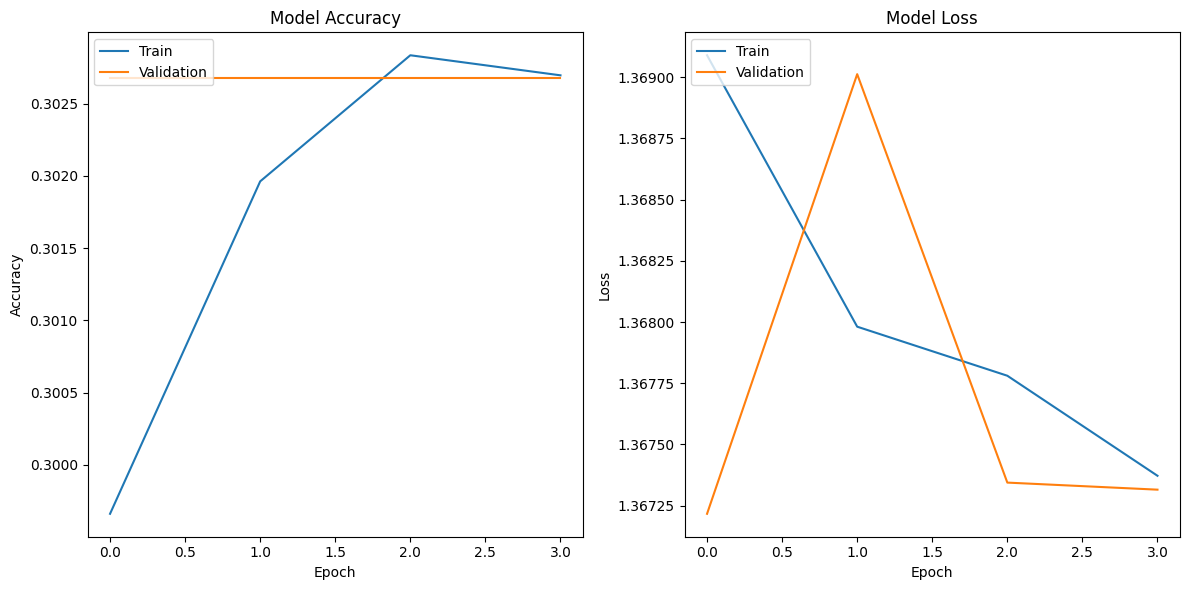

In [20]:
import matplotlib.pyplot as plt # Import Matplotlib for creating static, interactive, and animated visualizations.

# Create a figure with two subplots for visualizing accuracy and loss over epochs.
plt.figure(figsize=(12, 6))

# Subplot 1: Model Accuracy
plt.subplot(1, 2, 1) # (rows, columns, panel number)
plt.plot(history.history['accuracy']) # Plot training accuracy from the 'history' object.
plt.plot(history.history['val_accuracy']) # Plot validation accuracy.
plt.title('Model Accuracy') # Set the title of the subplot.
plt.ylabel('Accuracy') # Set the y-axis label.
plt.xlabel('Epoch') # Set the x-axis label.
plt.legend(['Train', 'Validation'], loc='upper left') # Add a legend to distinguish train/validation curves.

# Subplot 2: Model Loss
plt.subplot(1, 2, 2) # (rows, columns, panel number)
plt.plot(history.history['loss']) # Plot training loss.
plt.plot(history.history['val_loss']) # Plot validation loss.
plt.title('Model Loss') # Set the title of the subplot.
plt.ylabel('Loss') # Set the y-axis label.
plt.xlabel('Epoch') # Set the x-axis label.
plt.legend(['Train', 'Validation'], loc='upper left') # Add a legend.

plt.tight_layout() # Adjust subplot parameters for a tight layout, preventing labels from overlapping.
plt.show() # Display the plot.
# Rationale: Visualizing these trends helps in understanding the model's learning process,
# detecting overfitting (validation loss increases while training loss decreases) or underfitting (both losses are high).
# This is crucial for hyperparameter tuning and model improvement.

#### Task 17: Detect overfitting and underfitting using training and validation results

Based on the plots above, we can detect overfitting and underfitting:

*   **Underfitting:** If both the training and validation accuracy are low, or both loss curves remain high and flat, the model might be underfitting. This means the model is too simple to capture the patterns in the data.
*   **Overfitting:** If the training accuracy is significantly higher than the validation accuracy, or if the training loss continues to decrease while the validation loss starts to increase, the model is likely overfitting. This means the model has learned the training data too well, including its noise, and performs poorly on unseen data.
*   **Good Fit:** Ideally, both training and validation curves should converge and remain close to each other at a reasonable accuracy/loss level.

#### Task 18: Save and deploy the final trained model

In [21]:
import os # Import the 'os' module for interacting with the operating system, like creating directories.

# Define the directory name where the model and related assets will be saved.
model_save_dir = 'sentiment_model'

# Check if the directory already exists; if not, create it.
# 'os.path.exists()': Checks if a path exists.
# 'os.makedirs()': Creates directories recursively.
# Rationale: Ensures a clean location for saving model components.
if not os.path.exists(model_save_dir):
    os.makedirs(model_save_dir)

# Define the full path for saving the Keras model.
# 'os.path.join()': Concatenates path components intelligently based on the operating system.
model_path = os.path.join(model_save_dir, 'sentiment_lstm_model.keras')

# Save the entire Keras model (architecture, weights, and optimizer state).
# This allows the model to be reloaded later without needing to rebuild the architecture.
# Rationale: Essential for deploying the model for inference without retraining.
# Alternatives: Can save weights only ('model.save_weights()') and reload into a pre-defined architecture.
model.save(model_path)

print(f"Model saved to: {model_path}")

# Import the 'pickle' module for serializing Python objects.
import pickle

# Save the Tokenizer object.
# The tokenizer is critical for preprocessing new text data in the same way the training data was processed.
# 'open(..., 'wb')': Opens a file in binary write mode.
# 'pickle.dump()': Serializes the object to the file.
# 'protocol=pickle.HIGHEST_PROTOCOL': Uses the most efficient binary protocol.
# Rationale: Without the tokenizer, new text cannot be converted into numerical sequences that the model understands.
with open(os.path.join(model_save_dir, 'tokenizer.pickle'), 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Tokenizer saved to: {os.path.join(model_save_dir, 'tokenizer.pickle')}")

# Save the LabelEncoder object.
# The label encoder is needed to convert the model's numerical output (e.g., [0, 0, 0, 1]) back into human-readable sentiment labels (e.g., 'positive').
# Rationale: Ensures consistent mapping between numerical predictions and original sentiment categories.
with open(os.path.join(model_save_dir, 'label_encoder.pickle'), 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
print(f"Label Encoder saved to: {os.path.join(model_save_dir, 'label_encoder.pickle')}")


Model saved to: sentiment_model/sentiment_lstm_model.keras
Tokenizer saved to: sentiment_model/tokenizer.pickle
Label Encoder saved to: sentiment_model/label_encoder.pickle


### Easy-to-Understand Explanation of the Sentiment Analysis Notebook

This notebook walks us through building a system that can understand and categorize the sentiment (like positive, negative, neutral, or irrelevant) of text, such as user reviews or comments, using a technique called Deep Learning. Think of it like teaching a computer to read and understand emotions in text!

---

#### **Tasks 8 & 9: Setting Up and Looking at Our Data**

*   **What we did:** We imported the `pandas` library, which is like a powerful spreadsheet tool for Python. Then, we loaded our `Job_3_Resource_sentiment.csv` file, which contains all the text data we'll analyze, into something called a DataFrame (a table of data). We then peeked at the first few rows with `df.head()`.
*   **Why we did it:** Before doing anything fancy, we need to get our data ready. Importing `pandas` gives us the tools. Loading the CSV brings our data into our workspace. `df.head()` is super important because it gives us a quick look at how the data is structured, if it has proper column names, and if there are any immediate oddities.
*   **Alternatives:** There are other ways to load data (like from Excel or a database), but CSV is common. For initial inspection, we could also use `df.info()` to see data types or `df.describe()` for numerical summaries.

#### **Task 10: Getting Our Data Squeaky Clean**

This is a crucial stage because dirty or inconsistent data can confuse our learning model.

##### **Task 10.1: Fixing Column Headers**

*   **What we did:** When we first loaded the CSV, `df.head()` showed us that the first row of our file was actually data, not column names. So, we re-loaded the CSV telling pandas `header=None` (meaning no header), and then manually assigned clear names like 'ID', 'Game', 'Sentiment', and 'Text' to our columns using `df.columns = [...]`. We also made sure to remove any columns that weren't useful.
*   **Why we did it:** Imagine trying to sort books in a library if some shelves had labels and others didn't, or if the labels were wrong! Clear and correct column names make it easy for us and the computer to understand what each piece of information represents. If we didn't do this, the computer might mix up, say, the ID with the actual sentiment.
*   **Alternatives:** Sometimes CSVs come with correct headers. If the headers were slightly off, we might just rename specific columns. If the data format was very complex, more advanced parsing methods might be needed.

##### **Task 10.2: Dealing with Missing Stuff and Duplicates**

*   **What we did:** We checked for missing pieces of information (like empty text fields) using `df.isnull().sum()`. We also looked for completely identical rows using `df.duplicated().sum()`. If we found any duplicate rows, we removed them with `df.drop_duplicates(inplace=True)`.
*   **Why we did it:**
    *   **Missing Values:** Empty text fields aren't useful for sentiment analysis and can cause errors in our model. We need to decide whether to remove the rows with missing text or try to fill in the blanks (though for text, removing is often simpler).
    *   **Duplicates:** Having the exact same comment multiple times can unfairly influence our model. It's like a student practicing the same question over and over for a test—it might make them seem better than they are if that question is over-represented. Removing them ensures our model learns from unique examples.
*   **Alternatives:** For missing *numerical* data, we might fill it with the average or median. For missing text, we could try advanced techniques like generating text, but removal is simpler for this task. For duplicates, sometimes they are meaningful (e.g., repeated valid transactions), but here, they're noise.

##### **Task 10.3: Making Sentiment Labels Consistent**

*   **What we did:** We noticed that sentiment labels might be written in different ways (e.g., 'Positive', 'positive', ' Neutral ', 'negative'). We used `df['Sentiment'].str.strip().str.lower()` to remove any extra spaces around the words and convert everything to lowercase. So, ' Positive ' became 'positive'.
*   **Why we did it:** Our computer sees 'Positive' and 'positive' as two completely different things, even though they mean the same to us. To avoid confusion and ensure our model correctly groups all positive comments together, we standardize these labels. This is crucial for accurate classification.
*   **Alternatives:** We could use a custom mapping dictionary if the inconsistencies were more complex (e.g., mapping 'happy' to 'positive').

##### **Task 10.4: Basic Text Cleaning**

*   **What we did:** We created a function `clean_text` that does two main things: converts all text to lowercase and removes special characters (like !, @, #, etc.), leaving only letters, numbers, and spaces. It also fixes multiple spaces to be single spaces. We then applied this function to our 'Text' column to create a new 'cleaned_text' column.
*   **Why we did it:**
    *   **Lowercase:** Again, 'Hello' and 'hello' are different to a computer. Lowercasing reduces our vocabulary size and treats words uniformly.
    *   **Remove Special Characters:** Punctuation and symbols often don't add much to the core sentiment of a sentence (unless it's an emoji!), and they can clutter our data. Removing them simplifies the text and helps the model focus on the words themselves.
    *   **Fix Spaces:** Extra spaces are just visual clutter for us and computational clutter for the model.
*   **Alternatives:** Depending on the task, we might keep some punctuation (like exclamation marks for intensity). More advanced text cleaning might involve removing stop words (like 'the', 'a', 'is'), stemming (reducing words to their root, e.g., 'running' to 'run'), or lemmatization (linguistically reducing words to their base form).

#### **Task 11: Preparing Text for the Deep Learning Model (Feature Extraction)**

Deep learning models understand numbers, not words. So, we need to convert our cleaned text into numerical representations.

*   **What we did:**
    1.  **Tokenization:** We used `Tokenizer` to break down each sentence into individual words (tokens) and assigned a unique number to each word based on its frequency. For example, 'hello world' might become `[10, 25]` if 'hello' is word #10 and 'world' is word #25. We limited our vocabulary to `VOCAB_SIZE=10000` (the 10,000 most common words) and used `<OOV>` for words not in this top list.
    2.  **Padding:** Since all sentences fed into a deep learning model must be the exact same length, we used `pad_sequences`. This adds zeros to the end of shorter sentences and cuts off longer sentences to a `MAX_SEQUENCE_LENGTH=100` words.
    3.  **Encoding Sentiment Labels:** Our 'positive', 'negative', 'neutral', 'irrelevant' labels are text. We first used `LabelEncoder` to turn them into simple numbers (0, 1, 2, 3). Then, for deep learning models, we used `to_categorical` to convert these numbers into a special format called 'one-hot encoding'. For example, 'positive' (if it's 3) might become `[0, 0, 0, 1]`, meaning it's 100% 'positive' and 0% anything else.

*   **Why we did it:**
    *   **Tokenization:** It's the first step to translate human language into a format computers can process. By giving each word a number, the model can start to 'count' and 'identify' words.
    *   **Padding:** Deep learning models, especially LSTMs, require fixed-size inputs. Padding ensures all our text examples have a consistent shape, making them suitable for the model.
    *   **Encoding Labels:** Text labels (`'positive'`) cannot be directly used for calculations. Numerical labels are essential. One-hot encoding is specifically needed for classification tasks in deep learning because it treats each category equally and helps the model understand the probability of each outcome.

*   **Alternatives:**
    *   **Tokenization:** We could use techniques like TF-IDF (Term Frequency-Inverse Document Frequency) or Word2Vec/GloVe embeddings for more sophisticated word representations that capture semantic meaning. We're using a simpler tokenization here, and the `Embedding` layer will learn better representations later.
    *   **Padding:** Sometimes, 'pre' padding (adding zeros to the beginning) is used if the end of sentences is considered more important.
    *   **Encoding Labels:** For binary classification (only two outcomes), we might not need `to_categorical` and could use `sparse_categorical_crossentropy` if the labels are just integers.

#### **Task 12: Dividing Our Data for Fair Training (Splitting Dataset)**

*   **What we did:** We split our entire dataset into three distinct parts: `X_train`, `X_val`, `X_test` (and their corresponding `y_train`, `y_val`, `y_test` for labels).
    *   **Training Set (70%):** Used to teach the model.
    *   **Validation Set (15%):** Used during training to fine-tune the model and prevent it from memorizing the training data.
    *   **Test Set (15%):** Kept completely separate and unseen until the very end to give us a true, unbiased measure of how well our final model performs on new data.
    We used `train_test_split` from `sklearn` with `random_state=42` (for reproducibility) and `stratify=one_hot_labels`.

*   **Why we did it:** Imagine a student preparing for an exam:
    *   **Training Set:** This is like the practice questions the student uses to learn the material.
    *   **Validation Set:** This is like a mini-quiz the student takes every now and then to check if they're learning effectively or just memorizing. If they do great on practice questions but bad on the quiz, they're probably memorizing.
    *   **Test Set:** This is the actual final exam. The student has never seen these questions before. This gives a true measure of their understanding.
    Splitting the data this way prevents our model from 'cheating' by memorizing the data it was trained on (overfitting) and gives us an honest assessment of its real-world performance. `stratify` ensures that each split has a similar proportion of sentiment types, which is important if some sentiments are rarer than others.

*   **Alternatives:** The split percentages (e.g., 70/15/15) can be adjusted. For very large datasets, a smaller validation/test set might suffice. For smaller datasets, cross-validation (training and testing on different subsets multiple times) might be used.

#### **Task 13: Building Our Deep Learning Brain (Model Architecture)**

*   **What we did:** We designed our deep learning model using Keras's `Sequential` API, which means we stack layers one after another.
    1.  **Embedding Layer:** This is the first layer. It takes our padded numerical sequences of words and turns them into dense 'vectors' (lists of numbers). `EMBEDDING_DIM=128` means each word gets a list of 128 numbers.
    2.  **SpatialDropout1D Layer:** This layer randomly 'turns off' some of the connections in the embedding output (`0.2` means 20% are turned off).
    3.  **LSTM Layer:** This is the core 'brain' for understanding sequences. LSTM stands for Long Short-Term Memory, and it's a type of Recurrent Neural Network (RNN) that's really good at remembering information from earlier parts of a sequence. We set `LSTM_UNITS=128` and also added dropout (`dropout=0.2`, `recurrent_dropout=0.2`) here.
    4.  **Dense Layer (Output):** This is the final layer. It's a regular neural network layer that takes the output from the LSTM and compresses it down to `NUM_CLASSES` (which is 4, for our 4 sentiment types). It uses a `softmax` activation function, which gives us probabilities for each sentiment (e.g., 80% positive, 10% negative, etc.).

*   **Why we did it:**
    *   **Deep Learning Model:** These models are excellent at learning complex patterns in data, especially sequential data like text. They can discover subtle relationships that simple models might miss.
    *   **Embedding Layer:** Instead of just assigning arbitrary numbers to words, the embedding layer learns to represent words in a way that words with similar meanings have similar numerical vectors. This is a powerful way to capture semantics.
    *   **SpatialDropout1D & Dropout in LSTM:** These are regularization techniques. They randomly ignore certain parts of the network during training. This prevents the model from relying too heavily on any single feature or connection, making it more robust and less likely to overfit (memorize the training data).
    *   **LSTM Layer:** Text is sequential; the meaning of a word can depend on words that came before it. LSTMs are designed to 'remember' important information over long sequences, making them perfect for understanding context in sentences for sentiment analysis.
    *   **Dense Output Layer with Softmax:** This layer consolidates all the information learned by the previous layers and makes the final prediction. `softmax` is perfect for multi-class classification because it provides probabilities, telling us how confident the model is about each sentiment.

*   **Alternatives:**
    *   **Other RNNs:** GRUs (Gated Recurrent Units) are simpler and faster alternatives to LSTMs, often performing similarly.
    *   **Convolutional Neural Networks (CNNs):** CNNs are typically used for images but can also be adapted for text (TextCNNs) to capture local features (like n-grams).
    *   **Transformers:** More modern and powerful architectures like Transformers (used in models like BERT, GPT) are state-of-the-art for many NLP tasks, but they are much more complex and computationally intensive.

#### **Task 14: Teaching Our Model (Compile and Train)**

*   **What we did:**
    1.  **Compile:** We configured our model's learning process. We told it to use the `adam` optimizer (its 'learning strategy'), `categorical_crossentropy` as its 'mistake measuring' function, and `accuracy` as the metric to track its performance.
    2.  **Callbacks:** We added two smart tools:
        *   `EarlyStopping`: This stops training early if the model isn't improving on the validation data for a few training rounds (`patience=3`). It also keeps the 'best' version of the model.
        *   `ReduceLROnPlateau`: If the model's learning gets stuck (no improvement on validation loss for `patience=2` rounds), this tool slowly reduces the 'learning rate' (the step size the optimizer takes).
    3.  **Train (`model.fit`):** We started the actual learning! We fed the `X_train` (cleaned text data) and `y_train` (correct sentiment labels) to the model, telling it how many `EPOCHS` (full passes through the data) to run and the `BATCH_SIZE` (how many examples to process at once before updating its knowledge).

*   **Why we did it:**
    *   **Compile:** This is like giving a student instructions: what method to use for learning (`optimizer`), how to know if they made a mistake (`loss function`), and how to grade their performance (`metrics`).
    *   **Adam Optimizer:** Adam is a popular and generally effective strategy for adjusting the model's internal 'weights' (its knowledge) during learning. It's like a good teacher who adapts their methods based on how the student is doing.
    *   **Categorical Crossentropy:** This mathematically measures how 'wrong' our model's probability predictions are compared to the true sentiment. Lower values mean better predictions.
    *   **Accuracy:** This is simply the percentage of correct predictions the model makes. Easy to understand!
    *   **EarlyStopping:** Prevents overfitting and saves computation time. If the student isn't learning anything new from the practice exams (validation set), it's time to stop studying. This also ensures we get the version of the model that performed best, not just the last version.
    *   **ReduceLROnPlateau:** Sometimes the model gets stuck in a 'learning plateau'. Reducing the learning rate is like taking smaller, more careful steps, which can help the model find a better solution.
    *   **Train (`model.fit`):** This is where the model 'studies' the data, repeatedly adjusting its internal connections to minimize the `loss` and maximize `accuracy`.

*   **Alternatives:**
    *   **Optimizers:** Other optimizers include SGD, RMSprop, Adagrad. Adam is a good all-rounder.
    *   **Loss Functions:** For binary classification, `binary_crossentropy` would be used. For regression tasks, `mean_squared_error`.
    *   **Metrics:** Precision, recall, F1-score are other important metrics, especially for imbalanced datasets.

#### **Task 15: Checking How Well Our Model Did (Evaluation)**

*   **What we did:** After training, we used `model.evaluate(X_test, y_test)` to get the final loss and accuracy of our model on the `X_test` dataset. Remember, the test set is completely new data the model has never seen before.
*   **Why we did it:** This is the 'final exam' result. It tells us how well our trained model is expected to perform on real-world, unseen text. A high accuracy and low loss on the test set indicate a good, reliable model. If the test accuracy is much lower than the training accuracy, it suggests overfitting.
*   **Alternatives:** Besides overall accuracy, we could calculate more detailed metrics like precision, recall, and F1-score for each sentiment class, especially if some classes are more important or if the dataset is imbalanced.

#### **Tasks 16 & 17: Visualizing Performance and Spotting Problems (Overfitting/Underfitting)**

*   **What we did:** We plotted two graphs: one showing the `accuracy` over each training epoch (round) and another showing the `loss` over each epoch. Both graphs show two lines: one for the training data and one for the validation data.
*   **Why we did it:** These plots are our diagnostic tools. They help us visually understand the learning process:
    *   **Good Fit:** If both the training and validation lines for accuracy go up together and stay close, and both loss lines go down together and stay close, our model is learning well and generalizing to new data.
    *   **Underfitting:** If both training and validation accuracy lines stay low, or both loss lines stay high, our model isn't learning enough. It might be too simple, or it hasn't trained long enough.
    *   **Overfitting:** This is common. If the training accuracy keeps going up, but the *validation* accuracy starts to drop (or validation loss starts to go *up* while training loss keeps going down), it means our model has started memorizing the training data instead of learning general rules. It's like a student who memorized all the practice questions but can't apply the knowledge to new problems. Dropout layers and early stopping are techniques designed to combat this.
*   **Alternatives:** We could use other visualization libraries (like seaborn) or interactive plotting tools. For more rigorous analysis of overfitting, we could perform N-fold cross-validation.

#### **Task 18: Saving Our Smart Model for Future Use (Save and Deploy)**

*   **What we did:** We saved our entire trained deep learning model to a file (`sentiment_lstm_model.keras`). We also saved the `tokenizer` and `label_encoder` objects to separate `.pickle` files.
*   **Why we did it:** Saving the model is like freezing its brain at its smartest point. This allows us to:
    *   **Reuse it:** We don't have to train it all over again every time we want to analyze new text.
    *   **Deploy it:** We can integrate this saved model into other applications (like a website, a mobile app, or a larger system) to perform sentiment analysis in real-time.
    *   **Why save tokenizer and label encoder?** When we want to predict the sentiment of a new sentence, it needs to go through the *exact same* preprocessing steps (tokenization and numerical conversion) as the training data. Saving the `tokenizer` ensures this consistency. Similarly, the model will output numbers (e.g., `[0, 0, 0, 1]`), and we need the `label_encoder` to translate that back into human-readable sentiment (`'positive'`).
*   **Alternatives:** Keras models can be saved in different formats (e.g., TensorFlow SavedModel format). Other machine learning models might be saved using `joblib` or `ONNX` for cross-platform compatibility.